In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

%load_ext watermark
%watermark --python --machine
# Python packages versions
%watermark --packages jupyterlab --iversions --watermark

Python implementation: CPython
Python version       : 3.12.3
IPython version      : 9.10.0

Compiler    : GCC 13.3.0
OS          : Linux
Release     : 6.17.0-19-generic
Machine     : x86_64
Processor   : x86_64
CPU cores   : 14
Architecture: 64bit

jupyterlab: 4.5.4

matplotlib: 3.10.8
numpy     : 2.4.2
pandas    : 2.3.3

Watermark: 2.6.0



In [2]:
%load_ext autoreload
%autoreload 2

from mdverse.scrapers import stats

In [3]:
parquet_files = stats.list_parquet_files(
    [
        "../data/zenodo/2026-02-16",
        "../data/figshare/2026-03-10",
        "../data/mddb/2026-02-18",
        "../data/nomad/2026-02-18",
        "../data/atlas/2026-02-18",
        "../data/gpcrmd/2026-02-18",
    ]
)
datasets_df, files_df = stats.read_datasets_files_dataframes(parquet_files)

Reading data from: ../data/zenodo/2026-02-16/zenodo_datasets.parquet
Adding 2,373 datasets
Reading data from: ../data/zenodo/2026-02-16/zenodo_files.parquet
Adding 506,320 files
Reading data from: ../data/figshare/2026-03-10/figshare_datasets.parquet
Adding 1,373 datasets
Reading data from: ../data/figshare/2026-03-10/figshare_files.parquet
Adding 223,928 files
Reading data from: ../data/mddb/2026-02-18/mddb_datasets.parquet
Adding 5,079 datasets
Reading data from: ../data/mddb/2026-02-18/mddb_files.parquet
Adding 849,967 files
Reading data from: ../data/nomad/2026-02-18/nomad_datasets.parquet
Adding 16,119 datasets
Reading data from: ../data/nomad/2026-02-18/nomad_files.parquet
Adding 555,990 files
Reading data from: ../data/atlas/2026-02-18/atlas_files.parquet
Adding 5,814 files
Reading data from: ../data/atlas/2026-02-18/atlas_datasets.parquet
Adding 1,938 datasets
Reading data from: ../data/gpcrmd/2026-02-18/gpcrmd_files.parquet
Adding 2,414 files
Reading data from: ../data/gpcrmd/

In [15]:
# Aggregate datasets
datasets_agg = stats.aggregate_datasets(datasets_df)
datasets_agg

,number_of_datasets,date_first_dataset,date_last_dataset
dataset_repository_name,,,
atlas,1938,NaN,NaN
figshare,1373,2012-08-20,2026-03-09
gpcrmd,830,2017-03-23,2025-10-30
mdposit_cineca_node,310,2025-06-20,2025-11-10
mdposit_inria_node,719,2025-06-19,2025-11-06
mdposit_mmb_node,4050,2025-06-18,2026-02-10
nomad,16119,2021-05-13,2026-02-05
zenodo,2369,2014-11-19,2026-02-14


In [17]:
# Aggregate files
files_agg = stats.aggregate_files(files_df)
files_agg

,number_of_datasets,deposited_files,deposited_zip_files,deposited_file_size_in_GB,total_number_of_files
dataset_repository_name,,,,,
atlas,1938,5814,5814,10362.700600,5814
figshare,1373,8419,1026,1216.186979,223928
gpcrmd,432,2414,25,623.758935,2414
mdposit_cineca_node,310,251583,0,51.571834,251583
mdposit_inria_node,719,186293,0,1021.540981,186293
mdposit_mmb_node,4050,412091,0,15123.717498,412091
nomad,16115,555990,0,2188.822289,555990
zenodo,2370,36019,4893,26686.658247,506320


In [6]:
merged_df = (pd.merge(datasets_agg, files_agg, how="inner", on=["dataset_repository_name"], suffixes=("_from_datasets", "_from_files")))
merged_df.loc["total"] = merged_df.sum(numeric_only=True)
merged_df.style.format(thousands=",", precision=0)

,number_of_datasets_from_datasets,date_first_dataset,date_last_dataset,number_of_datasets_from_files,deposited_files,deposited_zip_files,deposited_file_size_in_GB,total_number_of_files
dataset_repository_name,,,,,,,,
atlas,"1,938",nan,nan,"1,938","5,814","5,814","10,363","5,814"
figshare,"1,373",2012-08-20,2026-03-09,"1,373","8,419","1,026","1,216","223,928"
gpcrmd,830,2017-03-23,2025-10-30,432,"2,414",25,624,"2,414"
mdposit_cineca_node,310,2025-06-20,2025-11-10,310,"251,583",0,52,"251,583"
mdposit_inria_node,719,2025-06-19,2025-11-06,719,"186,293",0,"1,022","186,293"
mdposit_mmb_node,"4,050",2025-06-18,2026-02-10,"4,050","412,091",0,"15,124","412,091"
nomad,"16,119",2021-05-13,2026-02-05,"16,115","555,990",0,"2,189","555,990"
zenodo,"2,369",2014-11-19,2026-02-14,"2,370","36,019","4,893","26,687","506,320"
total,"27,708",nan,nan,"27,307","1,458,623","11,758","57,275","2,144,433"


In [7]:
(files_df
 .loc[:, "file_type"]
 .value_counts()
 .head(n=20)
)

file_type
jpg     337281
bin     311724
pdb     228081
xtc     102582
gro      95825
mdp      84347
itp      68084
tpr      65840
log      57951
xvg      54466
cpt      52170
edr      51194
out      45858
dat      44047
         40613
traj     27219
top      26269
txt      23139
xyz      21491
npz      15509
Name: count, dtype: int64

,dataset_repository_name,dataset_id_in_repository,dataset_url_in_repository,file_name,file_url_in_repository,file_size_in_bytes,file_md5,containing_archive_file_name,file_type,file_size_with_human_readable_unit,_is_zip_file,_size_not_from_zip_file,_is_not_from_zip_file
5,zenodo,259335,https://zenodo.org/records/259335,md30.gro,https://zenodo.org/api/records/259335/files/md...,4154274.0,97ebfe98a83452b76730591888dd8962,None,gro,4.2 MB,False,0.004154,True
11,zenodo,259335,https://zenodo.org/records/259335,md20.gro,https://zenodo.org/api/records/259335/files/md...,3970458.0,2012e2478f2e017a8b2c695836a9b4f7,None,gro,4.0 MB,False,0.003970,True
17,zenodo,259335,https://zenodo.org/records/259335,md10.gro,https://zenodo.org/api/records/259335/files/md...,3827490.0,4c9a0b7b4bc99bc43e1bf7e62a2bb3a4,None,gro,3.8 MB,False,0.003827,True
24,zenodo,259335,https://zenodo.org/records/259335,md0_370.gro,https://zenodo.org/api/records/259335/files/md...,3715157.0,829a3fe308c3261f28382edad4d67c29,None,gro,3.7 MB,False,0.003715,True
27,zenodo,259335,https://zenodo.org/records/259335,md0_330.gro,https://zenodo.org/api/records/259335/files/md...,3715157.0,4df63c860106a241167f8c0ab4265f45,None,gro,3.7 MB,False,0.003715,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2144417,gpcrmd,2358,https://www.gpcrmd.org/dynadb/dynamics/id/2358/,tmp_dyn_0_2714.pdb,https://www.gpcrmd.org/dynadb/files/Dynamics/d...,17308077.0,None,None,pdb,17.3 MB,False,0.017308,True
2144420,gpcrmd,2359,https://www.gpcrmd.org/dynadb/dynamics/id/2359/,tmp_dyn_0_2716.pdb,https://www.gpcrmd.org/dynadb/files/Dynamics/d...,478830.0,None,None,pdb,478.8 KB,False,0.000479,True
2144424,gpcrmd,2375,https://www.gpcrmd.org/dynadb/dynamics/id/2375/,tmp_dyn_0_2733.pdb,https://www.gpcrmd.org/dynadb/files/Dynamics/d...,375957.0,None,None,pdb,376.0 KB,False,0.000376,True
2144427,gpcrmd,2377,https://www.gpcrmd.org/dynadb/dynamics/id/2377/,tmp_dyn_0_2735.pdb,https://www.gpcrmd.org/dynadb/files/Dynamics/d...,6342851.0,None,None,pdb,6.3 MB,False,0.006343,True


In [23]:
file_types = ["pdb", "gro"]
tmp_files_df = (files_df
    .query("file_type in @file_types")
)
files_with_date_df = (
    pd.merge(
        tmp_files_df,
        datasets_df[["dataset_repository_name", "dataset_id_in_repository", "date_created"]],
        how="left",
        on=["dataset_repository_name", "dataset_id_in_repository"]
    )
)
files_with_date_df["year"] = pd.to_datetime(files_with_date_df["date_created"]).dt.year
years_df = (files_with_date_df
 .query("year != 2026")
 .groupby(["year", "dataset_repository_name"])
 .size().unstack()
)
years_df.style.format(thousands=",", precision=0)

dataset_repository_name,figshare,gpcrmd,mdposit_cineca_node,mdposit_inria_node,mdposit_mmb_node,nomad,zenodo
year,,,,,,,
2012.000000,10,nan,nan,nan,nan,nan,nan
2013.000000,7,nan,nan,nan,nan,nan,nan
2014.000000,63,nan,nan,nan,nan,nan,3
2015.000000,157,nan,nan,nan,nan,nan,53
2016.000000,899,nan,nan,nan,nan,nan,239
2017.000000,250,2,nan,nan,nan,nan,598
2018.000000,128,155,nan,nan,nan,nan,225
2019.000000,751,34,nan,nan,nan,nan,"1,780"
2020.000000,808,14,nan,nan,nan,nan,"3,076"


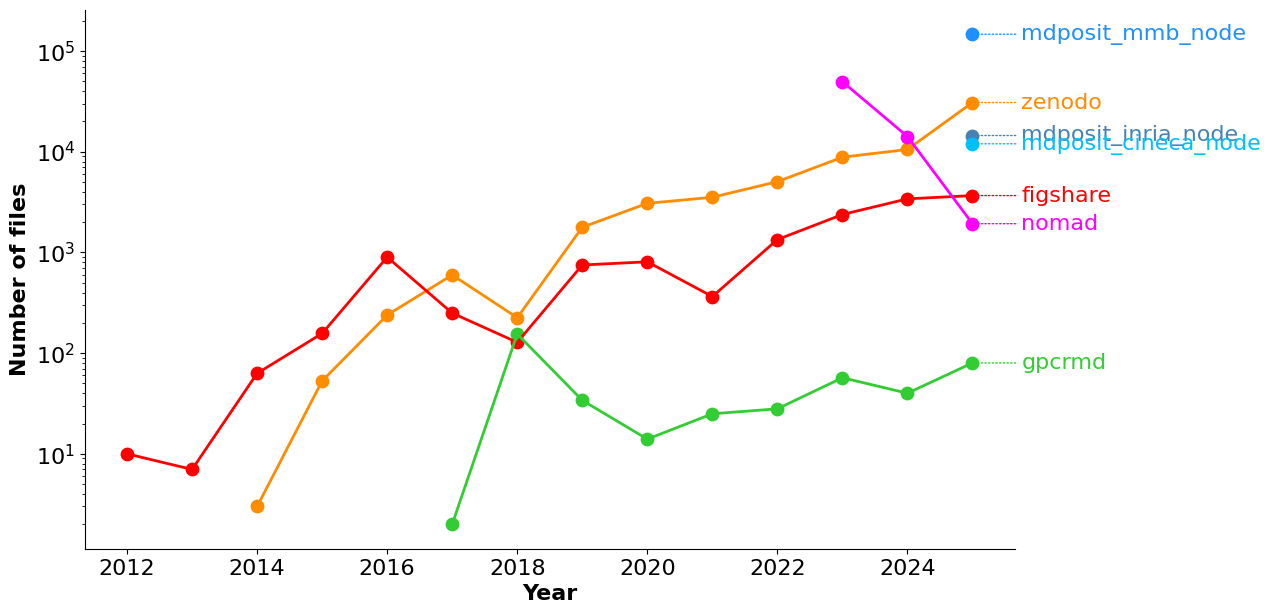

In [29]:
plt.rcParams.update({"font.size": 16})
fig, ax = plt.subplots(figsize=(12, 7))
data_repositories = [
    {"name": "zenodo", "offset": 0, "color": "darkorange"},
    {"name": "figshare", "offset": 0, "color": "red"},
    {"name": "gpcrmd", "offset": 0, "color": "limegreen"},
    {"name": "mdposit_mmb_node", "offset": 0, "color": "dodgerblue"},
    {"name": "mdposit_inria_node", "offset": 0, "color": "steelblue"},
    {"name": "mdposit_cineca_node", "offset": 0, "color": "deepskyblue"},
    {"name": "nomad", "offset": 0, "color": "magenta"},
]
for repo in data_repositories:
    tmp_df = years_df[repo["name"]].dropna()
    ax.scatter(tmp_df.index, tmp_df, label=repo["name"], color=repo["color"], s=80)
    ax.plot(tmp_df.index, tmp_df, ls="-", color=repo["color"], linewidth=2)
    ax.annotate(
        repo["name"],
        xy=(tmp_df.index[-1], tmp_df.iloc[-1]),
        xytext=(tmp_df.index[-1] + 0.75, tmp_df.iloc[-1] + repo["offset"]),
        textcoords="data",
        color=repo["color"],
        va="center",
        ha="left",
        arrowprops=dict(edgecolor=repo["color"], arrowstyle="-", linestyle=":", linewidth=1)
    )
ax.set_xlabel("Year", weight="bold")
ax.set_ylabel("Number of files", weight="bold")
ax.set_yscale("log")  # Convert y-axis to logarithmic scale
ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)

#filename = "number_of_files_per_years_per_data_repositories"
#plt.savefig(f"{filename}.png", dpi=300, bbox_inches="tight")
#plt.savefig(f"{filename}.svg", bbox_inches="tight")